# Break Through Tech AI: Nestlé 1A Group
## Stage 1: Building the DataFrame

As of 09/06/2025, the Nestlé 1A group has decided to use a subset of the [Amazon Reviews](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) dataset collected in 2023 by McAuley Lab. The entire dataset consists of 571.54 M examples. We are using the raw data from the "Grocery and Gourmet Food" category, which consists of over 14 M examples, to build an initial dataframe to then preprocess and develop machine learning models from.

Note: Outputs have been cleared due to rendering issues. Please run on your personal machine.

#### Step 0. Update, Install, and Import Python Libraries

In [53]:
# !pip install --upgrade pip
# !pip install -q datasets huggingface_hub pyarrow pandas
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn
# !pip install seaborn

In [2]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from tqdm import tqdm
import json
import pandas as pd
import pyarrow as pa

#### Step 1. Upload User Reviews file from HuggingFace

In [3]:
REV_PATH = "raw/review_categories/Grocery_and_Gourmet_Food.jsonl"

In [4]:
rev_file = hf_hub_download(repo_id="McAuley-Lab/Amazon-Reviews-2023", filename=REV_PATH, repo_type="dataset",)

In [5]:
ds_rev = load_dataset("json", data_files=rev_file, split="train")

In [6]:
# Note: This cell may take a while to run.
df_rev = ds_rev.to_pandas()

##### Data Fields for User Reviews

| Field            | Type   | Explanation |
| :--------------- | :----- | :---------- |
| rating           | float  | Rating of the product (from 1.0 to 5.0). |
| text             | str    | Text body of the user review. |
| images           | list   | Images that users post after they have received the product.<br><br>Note: Each image has different sizes (small, medium, large), represented by the `small_image_url`, `medium_image_url`, and `large_image_url` respectively. |
| asin             | str    | ID of the product. |
| parent_asin      | str    | Parent ID of the product.<br><br>Note: Products with different colors, styles, sizes usually belong to the same parent ID. The “asin” in previous Amazon datasets is actually parent ID. Please use parent ID to find product meta. |
| user_id          | str    | ID of the reviewer. |
| timestamp        | int    | Time of the review (unix time). |
| verified_purchase| bool   | User purchase verification. |
| helpful_vote     | int    | Helpful votes of the review. |

#### Step 2. Upload Item Metadata file from HuggingFace

In [7]:
META_PATH = "raw/meta_categories/meta_Grocery_and_Gourmet_Food.jsonl"

In [8]:
# Filters down to only products with reviews
needed_parent_asin = set(df_rev["parent_asin"].unique())

In [9]:
# Loading metadata
meta_file = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename=META_PATH,
    repo_type="dataset",
)


In [10]:
# Selected few columns from metadata
meta_rows = []
with open(meta_file, "r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Parsing meta file"):
        obj = json.loads(line)
        row = {
            "parent_asin": obj.get("parent_asin"),
            "title_meta": obj.get("title"),
            "main_category": obj.get("main_category"),
            "average_rating": obj.get("average_rating"),
            "rating_number": obj.get("rating_number"),
            "price": obj.get("price"),
            "details": obj.get("details")  # keep raw JSON dict for now
        }
        # Filters down to only products with reviews
        if row["parent_asin"] not in needed_parent_asin:
            continue
        meta_rows.append(row)

Parsing meta file: 603274it [00:09, 62400.14it/s]


In [11]:
df_meta = pd.DataFrame(meta_rows)

##### Data Fields for Item Metadata

| Field           | Type  | Explanation |
| :--------------- | :---- | :---------- |
| main_category    | str   | Main category (i.e., domain) of the product. |
| title            | str   | Name of the product. |
| average_rating   | float | Rating of the product shown on the product page. |
| rating_number    | int   | Number of ratings in the product. |
| features         | list  | Bullet-point format features of the product. |
| description      | list  | Description of the product. |
| price            | float | Price in US dollars (at time of crawling). |
| images           | list  | Images of the product. Each image has different sizes (thumb, large, hi_res). The “variant” field shows the position of the image. |
| videos           | list  | Videos of the product, including title and URL. |
| store            | str   | Store name of the product. |
| categories       | list  | Hierarchical categories of the product. |
| details          | dict  | Product details, including materials, brand, sizes, etc. |
| parent_asin      | str   | Parent ID of the product. |
| bought_together  | list  | Recommended bundles from the website. |


#### Step 3. Data Cleaning: Remove Duplicates, Handle Missing Values, Only Include Verified Purchases


##### Step 3a. User Reviews DataFrame

In [12]:
print("Shape before dropping duplicates:", df_rev.shape)

Shape before dropping duplicates: (14318520, 10)


In [13]:
# Check for duplicate reviews based on user_id, asin, and text
dup_count = df_rev.duplicated(subset=["user_id", "asin", "text"]).sum()
print("Total duplicate reviews:", dup_count)

Total duplicate reviews: 130960


In [14]:
# Drop duplicate reviews
df_rev = df_rev.drop_duplicates(subset=["user_id", "asin", "text"])
print("Shape after dropping duplicates:", df_rev.shape)

Shape after dropping duplicates: (14187560, 10)


In [15]:
# Count missing ratings
print("Missing ratings:", df_rev['rating'].isna().sum())

Missing ratings: 0


In [16]:
# Remove missing or empty review text
df_rev = df_rev.dropna(subset=['text'])
df_rev = df_rev[df_rev['text'].str.strip() != '']

In [17]:
# Count missing helpful_vote
print("Missing helpful_vote:", df_rev['helpful_vote'].isna().sum())

Missing helpful_vote: 0


In [18]:
# Count missing verified_purchase
print("Missing verified_purchase:", df_rev['verified_purchase'].isna().sum())

Missing verified_purchase: 0


In [20]:
df_rev['verified_purchase'].value_counts()

verified_purchase
True     13040805
False     1130177
Name: count, dtype: int64

In [21]:
df_rev = df_rev[df_rev['verified_purchase'] == True]

In [27]:
print("Final df_rev shape:", df_rev.shape)

Final df_rev shape: (13040805, 10)


##### Step 3b. Item Metadata DataFrame

In [28]:
print("Initial df_meta shape:", df_meta.shape)

Initial df_meta shape: (603182, 7)


In [21]:
print("Missing ratings:", df_meta['average_rating'].isna().sum())

Missing ratings: 0


#### Step 4. Merge the User Reviews and Item Metadata DataFrames into one

In [30]:
df = df_rev.merge(
    df_meta,
    on="parent_asin", how="left"
)

#### Step 5. Convert the file for Data Preprocessing

In [31]:
# Export merged dataframe as parquet chunks
import gc
import numpy as np

chunk_size = 1000000  # 1M records per chunk
total_chunks = len(df) // chunk_size + 1

for i in tqdm(range(0, len(df), chunk_size)):
    chunk = df.iloc[i:i+chunk_size]
    chunk['price'] = pd.to_numeric(df['price'].replace('—', np.nan), errors='coerce')
    chunk.to_parquet(f'df_chunk_{i//chunk_size:03d}.parquet', index=False)
    del chunk
    gc.collect()
    
print(f"Exported {total_chunks} parquet chunks")

  0%|          | 0/14 [00:00<?, ?it/s]/var/folders/c9/wn2xf92x7p91gfpzb9dzjm2c0000gn/T/ipykernel_35306/3602230608.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  chunk['price'] = pd.to_numeric(df['price'].replace('—', np.nan), errors='coerce')
/var/folders/c9/wn2xf92x7p91gfpzb9dzjm2c0000gn/T/ipykernel_35306/3602230608.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['price'] = pd.to_numeric(df['price'].replace('—', np.nan), errors='coerce')
100%|██████████| 14/14 [16:33<00:00, 70.98s/it]

Exported 14 parquet chunks


#### Step 6. Flavor Analysis

In [32]:
# View flavors from 'details' column and their mention counts 
df["details"].str.get("Flavor").value_counts()

details
Chocolate                                                              87946
Assorted                                                               66497
Original                                                               41223
Caramel                                                                33947
Vanilla                                                                31154
                                                                       ...  
Cherry, Watermelon, Strawberry, Mango, Grapefruit, Pineapple, Lemon        1
Brussels                                                                   1
Honey,Teriyaki                                                             1
Matcha,Green,Blueberry                                                     1
Strawberry,Vanilla                                                         1
Name: count, Length: 28581, dtype: int64

In [33]:
df['timestamp'].head(10)

0    1587854482395
1    1587854400380
2    1587853224527
3    1581313319614
4    1581313294965
5    1581313263026
6    1552878483550
7    1552878387841
8    1552878262155
9    1552878208860
Name: timestamp, dtype: int64

In [34]:
# Convert timestamps to actual date&time format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')


In [35]:
df['timestamp'].head()

0   2020-04-25 22:41:22.395
1   2020-04-25 22:40:00.380
2   2020-04-25 22:20:24.527
3   2020-02-10 05:41:59.614
4   2020-02-10 05:41:34.965
Name: timestamp, dtype: datetime64[ns]

In [36]:
# Create year_quarter column in df
df['year_quarter'] = df['timestamp'].dt.to_period('Q')
df[['timestamp', 'year_quarter']].head()


,timestamp,year_quarter
0,2020-04-25 22:41:22.395,2020Q2
1,2020-04-25 22:40:00.380,2020Q2
2,2020-04-25 22:20:24.527,2020Q2
3,2020-02-10 05:41:59.614,2020Q1
4,2020-02-10 05:41:34.965,2020Q1


In [37]:
# View first row of 'details' column
df['details'].iloc[0]

{'Package Dimensions': '9.49 x 7.68 x 4.76 inches; 0.64 Ounces',
 'UPC': '757107011131',
 'Manufacturer': 'VEETEE RICE Inc'}

In [38]:
# Define a list of generic flavor terms to exclude
generic_flavors = ['Original', 'Assorted', 'Variety', 'Mixed', 'Classic', 'Regular', 'Plain']

df['Flavor'] = df['details'].apply(lambda x: x.get('Flavor') if isinstance(x, dict) and 'Flavor' in x else None)

# Drop rows with generic or missing flavors
df = df[~df['Flavor'].isin(generic_flavors)]
df = df.dropna(subset=['Flavor'])

# View flavor and its number of mentions
df['Flavor'].value_counts().head(10)

Flavor
Chocolate         87946
Caramel           33947
Vanilla           31154
Fruit             28362
Milk Chocolate    27756
Coffee            27696
Cinnamon          24051
Cherry            22329
Dark Chocolate    21199
Espresso          19860
Name: count, dtype: int64

In [39]:
df['Flavor'].head(20)

10                          Blueberry
17                        Meyer Lemon
29                   Variety - 3 Pack
32               Cinnamon Bark Powder
35                 Flavored Chocolate
36                              Pizza
41                     black licorice
42                         Unflavored
44                             Coffee
45                  Whole Bean Coffee
65                        Butter Cake
66                         Peppermint
98                  Toasted Corn Nuts
112                          Hazelnut
115                    Milk Chocolate
117                    Milk Chocolate
125                           Caramel
139                  Bold & Brilliant
146    Honey,Honey Roasted,Mixed Nuts
148                          Licorice
Name: Flavor, dtype: object

In [40]:
df['Flavor'].isna().sum() 

np.int64(0)

In [41]:
total_rows = len(df)
flavor_rows = df['Flavor'].notna().sum()
print(f"Keeping {flavor_rows/total_rows:.2%} of rows with valid flavor info")

Keeping 100.00% of rows with valid flavor info


In [42]:
df['Flavor'].notna().sum()

np.int64(2318509)

In [43]:
# find the top mentioned flavors within our dataframe
top_flavors = (df['Flavor'].value_counts().head(100).index)
# Create a dataframe for top flavors
df_top = df[df['Flavor'].isin(top_flavors)].copy()

In [44]:
# Convert timestamp to the correct date&time format
df_top['timestamp'] = pd.to_datetime(df_top['timestamp'], unit='ms', errors='coerce')
# Create quarter column based on timestamps
df_top['year_quarter'] = df_top['timestamp'].dt.to_period('Q')

In [45]:
df_top[['timestamp', 'year_quarter']].head()

,timestamp,year_quarter
10,2019-01-23 01:46:28.441,2019Q1
42,2020-05-13 15:36:41.181,2020Q2
44,2018-09-06 01:14:49.930,2018Q3
45,2015-03-06 15:53:40.000,2015Q1
66,2015-12-11 00:52:25.000,2015Q4


In [46]:
# Group data by flavors and quarter
trend_df = (df_top.groupby(['year_quarter', 'Flavor']).size().reset_index(name='mention_count'))


In [47]:
# Sort flavor quarters in chronological order
trend_df = trend_df.sort_values(by=['Flavor', 'year_quarter'])

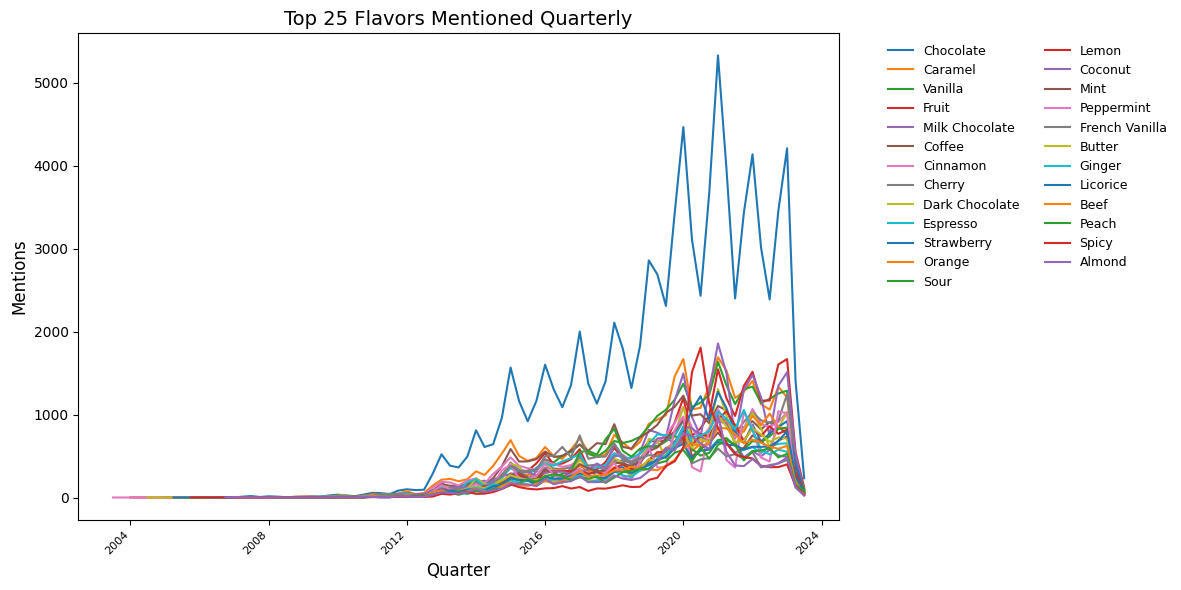

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

top25 = df_top['Flavor'].value_counts().head(25).index

for flavor in top25:
    subset = trend_df[trend_df['Flavor'] == flavor].sort_values('year_quarter')
    plt.plot(subset['year_quarter'].dt.to_timestamp(),   # ensures correct order
             subset['mention_count'],
             label=flavor)

plt.title("Top 25 Flavors Mentioned Quarterly", fontsize=14)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Mentions", fontsize=12)

# Rotate and shrink x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=8)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9, frameon=False)

# Use tight layout to fit everything neatly 
plt.tight_layout()
plt.show()


In [49]:
# Compute growth rate quarter over quarter
trend_df['growth_rate'] = trend_df.groupby('Flavor')['mention_count'].pct_change()

In [50]:
trend_df.head(10)

,year_quarter,Flavor,mention_count,growth_rate
37,2006Q4,Almond,2,NaN
55,2007Q1,Almond,4,1.0
90,2007Q2,Almond,2,-0.5
118,2007Q3,Almond,1,-0.5
304,2008Q4,Almond,1,0.0
353,2009Q1,Almond,1,0.0
405,2009Q2,Almond,1,0.0
511,2009Q4,Almond,1,0.0
577,2010Q1,Almond,5,4.0
645,2010Q2,Almond,2,-0.6


In [51]:
# Find most consistently growing flavors
top_growing = trend_df.groupby('Flavor')['growth_rate'].mean().sort_values(ascending=False)

In [52]:
# Calculate top 25 flavors with highest growth rate
top_growing = trend_df.groupby('Flavor')['growth_rate'].mean().sort_values(ascending=False).head(25)
top_growing.head(25)

Flavor
Whole Bean Coffee            0.861529
Cookies & Cream              0.772826
Party Mix                    0.768104
Just Black (Medium Roast)    0.544458
Milk Chocolate               0.516517
Cookies                      0.452031
Raw                          0.447292
Salty,Sweet                  0.374176
Matcha                       0.351290
Peppermint                   0.343959
Pumpkin Spice                0.328565
Grape                        0.323083
Pineapple                    0.291776
Apple                        0.276376
Zero ultra                   0.269234
Caramel                      0.267620
Decaf                        0.256848
Cheese                       0.254652
Raspberry                    0.247846
Peanut                       0.246828
Beef                         0.243844
Sweet                        0.243286
Chicken                      0.231138
Sweet & Hot                  0.230714
White Chocolate              0.228468
Name: growth_rate, dtype: float64